# Dataset Understanding & Preprocessing  
## PVDAQ – Farm Solar Array (2017–2024)

### Contexte du système photovoltaïque

Le dataset provient de la plateforme **PVDAQ** et correspond au site **Farm Solar Array**, un champ photovoltaïque au sol instrumenté pour la recherche et la surveillance de performance.

**Caractéristiques physiques du champ PV :**
- **Type d’irradiance mesurée** : Plane of Array (**POA**)
- **Azimut du champ** : 180° (plein sud)
- **Inclinaison (tilt)** : 25°
- **Configuration** : champ fixe au sol (pas de suivi solaire)
- **Nombre de canaux de capteurs disponibles** : 125
- **Période couverte** : novembre 2017 → novembre 2024

In [1]:
import pandas as pd
import re
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pvlib
from solardatatools.algorithms.shade import ShadeAnalysis
from solardatatools import DataHandler

Focusing only on electrical data.

In [2]:
# On a récupéré le dataset PVDAQ pour le système Farm Solar Array pour l'année 2024
# https://openei.org/wiki/PVDAQ/Sites/Farm_Solar_Array

df1 = pd.read_csv("pvdaq_data_2017_a_2023/2107_electrical_data_v1.csv", parse_dates=['measured_on'])

df2 = pd.read_csv("pvdaq_data_2024/2107_electrical_data_2024.csv", parse_dates=['measured_on'])


# Concaténation
df = pd.concat([df1, df2], ignore_index=True)

In [3]:
df['measured_on'] = pd.to_datetime(df['measured_on'])

### Nettoyage des identifiants des capteurs à la fin des noms des colonnes pour plus de clarté.

In [4]:
def clean_column_name(col):
    # supprime _inv_XXXXX ou _o_XXXXX
    return re.sub(r"_(inv|o|meter)_[0-9]+$", "", col)

df.columns = [clean_column_name(c) for c in df.columns]

print(df.columns)


Index(['measured_on', 'inv_01_dc_current', 'inv_01_dc_voltage',
       'inv_01_ac_current', 'inv_01_ac_voltage', 'inv_01_ac_power',
       'inv_02_dc_current', 'inv_02_dc_voltage', 'inv_02_ac_current',
       'inv_02_ac_voltage',
       ...
       'inv_23_dc_voltage', 'inv_23_ac_current', 'inv_23_ac_voltage',
       'inv_23_ac_power', 'inv_24_dc_current', 'inv_24_dc_voltage',
       'inv_24_ac_current', 'inv_24_ac_voltage', 'inv_24_ac_power',
       'inv_05_dc_voltage'],
      dtype='object', length=121)


### **Exploration du dataset**

In [5]:
df.head()

,measured_on,inv_01_dc_current,inv_01_dc_voltage,inv_01_ac_current,inv_01_ac_voltage,inv_01_ac_power,inv_02_dc_current,inv_02_dc_voltage,inv_02_ac_current,inv_02_ac_voltage,...,inv_23_dc_voltage,inv_23_ac_current,inv_23_ac_voltage,inv_23_ac_power,inv_24_dc_current,inv_24_dc_voltage,inv_24_ac_current,inv_24_ac_voltage,inv_24_ac_power,inv_05_dc_voltage
0,2017-11-01 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
1,2017-11-01 00:05:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
2,2017-11-01 00:10:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
3,2017-11-01 00:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
4,2017-11-01 00:20:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN


In [6]:
print(df.dtypes)

measured_on          datetime64[ns]
inv_01_dc_current           float64
inv_01_dc_voltage           float64
inv_01_ac_current           float64
inv_01_ac_voltage           float64
                          ...      
inv_24_dc_voltage           float64
inv_24_ac_current           float64
inv_24_ac_voltage           float64
inv_24_ac_power             float64
inv_05_dc_voltage           float64
Length: 121, dtype: object


In [7]:
print(df.shape)

(721067, 121)


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 721067 entries, 0 to 721066
Columns: 121 entries, measured_on to inv_05_dc_voltage
dtypes: datetime64[ns](1), float64(120)
memory usage: 665.7 MB


In [9]:
df.describe()

,measured_on,inv_01_dc_current,inv_01_dc_voltage,inv_01_ac_current,inv_01_ac_voltage,inv_01_ac_power,inv_02_dc_current,inv_02_dc_voltage,inv_02_ac_current,inv_02_ac_voltage,...,inv_23_dc_voltage,inv_23_ac_current,inv_23_ac_voltage,inv_23_ac_power,inv_24_dc_current,inv_24_dc_voltage,inv_24_ac_current,inv_24_ac_voltage,inv_24_ac_power,inv_05_dc_voltage
count,721067,720701.000000,720701.000000,720701.000000,720701.000000,720701.000000,720701.000000,720701.000000,720701.000000,720701.000000,...,719339.000000,719339.000000,719339.000000,719339.000000,719339.000000,719339.000000,719339.000000,719339.000000,719339.000000,88115.000000
mean,2021-04-12 14:23:35.220222976,10.048740,324.225028,7.574248,138.822367,6.462890,9.457658,321.533215,7.148834,137.839184,...,335.557690,7.791132,143.966953,6.657284,9.708505,331.544184,7.458524,141.916696,6.378354,350.119812
min,2017-11-01 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2019-07-20 00:12:30,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2021-04-06 00:25:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,304.505000,0.000000,267.571000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,576.861000
75%,2022-12-22 23:37:30,16.867000,674.209000,13.283000,286.134000,11.274000,14.861000,672.656000,11.837000,286.920000,...,678.534000,13.853000,286.396000,11.828000,15.756000,679.002000,12.643000,286.016000,10.835000,660.899000
max,2024-11-01 23:55:00,52.348000,909.840000,36.363000,310.677000,30.096000,54.844000,1750.755000,36.103000,310.508000,...,913.080000,35.848000,310.822000,30.106000,55.051000,912.795000,36.066000,310.605000,30.089000,851.387000
std,NaN,15.412937,336.704984,11.385872,143.151300,9.946591,15.065469,335.969491,11.057631,143.447015,...,337.712739,11.605694,143.200949,10.169255,15.269632,338.376586,11.337245,143.058397,9.959023,327.208967


### Détection des valeurs manquantes

In [10]:
missing = df.isna().sum()
missing = missing[missing > 0]

missing

inv_01_dc_current       366
inv_01_dc_voltage       366
inv_01_ac_current       366
inv_01_ac_voltage       366
inv_01_ac_power         366
                      ...  
inv_24_dc_voltage      1728
inv_24_ac_current      1728
inv_24_ac_voltage      1728
inv_24_ac_power        1728
inv_05_dc_voltage    632952
Length: 115, dtype: int64

Les valeurs manquantes dans les séries électriques sont conservées car elles sont informatives : elles représentent des périodes où les onduleurs ne produisent pas, sont hors ligne ou ne rapportent pas de données. Les interpoler ou les remplir pourrait masquer de véritables anomalies de production.

In [11]:
print("Plage des dates où les mesures ont été réalisées")
print(df['measured_on'].min())
print(df['measured_on'].max())


print("\nNombre de points par jours en moyenne")
daily_counts = df['measured_on'].dt.date.value_counts().sort_index()
print(np.average(daily_counts))

Plage des dates où les mesures ont été réalisées
2017-11-01 00:00:00
2024-11-01 23:55:00

Nombre de points par jours en moyenne
287.96605431309905


### Vérification physique de la relation entre puissance, courant et tension

Sur le côté AC:

`P ≈ V x I` 

On ne va sélectionner que quelques onduleurs pour le test.

In [12]:
inverters = [1, 5, 12, 20]

# On travaille sur un sous-ensemble sans valeurs manquantes
subset = df.copy()

for inv in inverters:
    subset[f'inv_{inv:02d}_p_calc'] = (
        subset[f'inv_{inv:02d}_ac_voltage'] *
        subset[f'inv_{inv:02d}_ac_current']
    )

# On garde quelques lignes représentatives en journée
sample = subset[
    (subset['measured_on'].dt.hour >= 10) &
    (subset['measured_on'].dt.hour <= 14)
].sample(200, random_state=42)


#### *Visualisation : cohérence P mesurée vs P calculée*

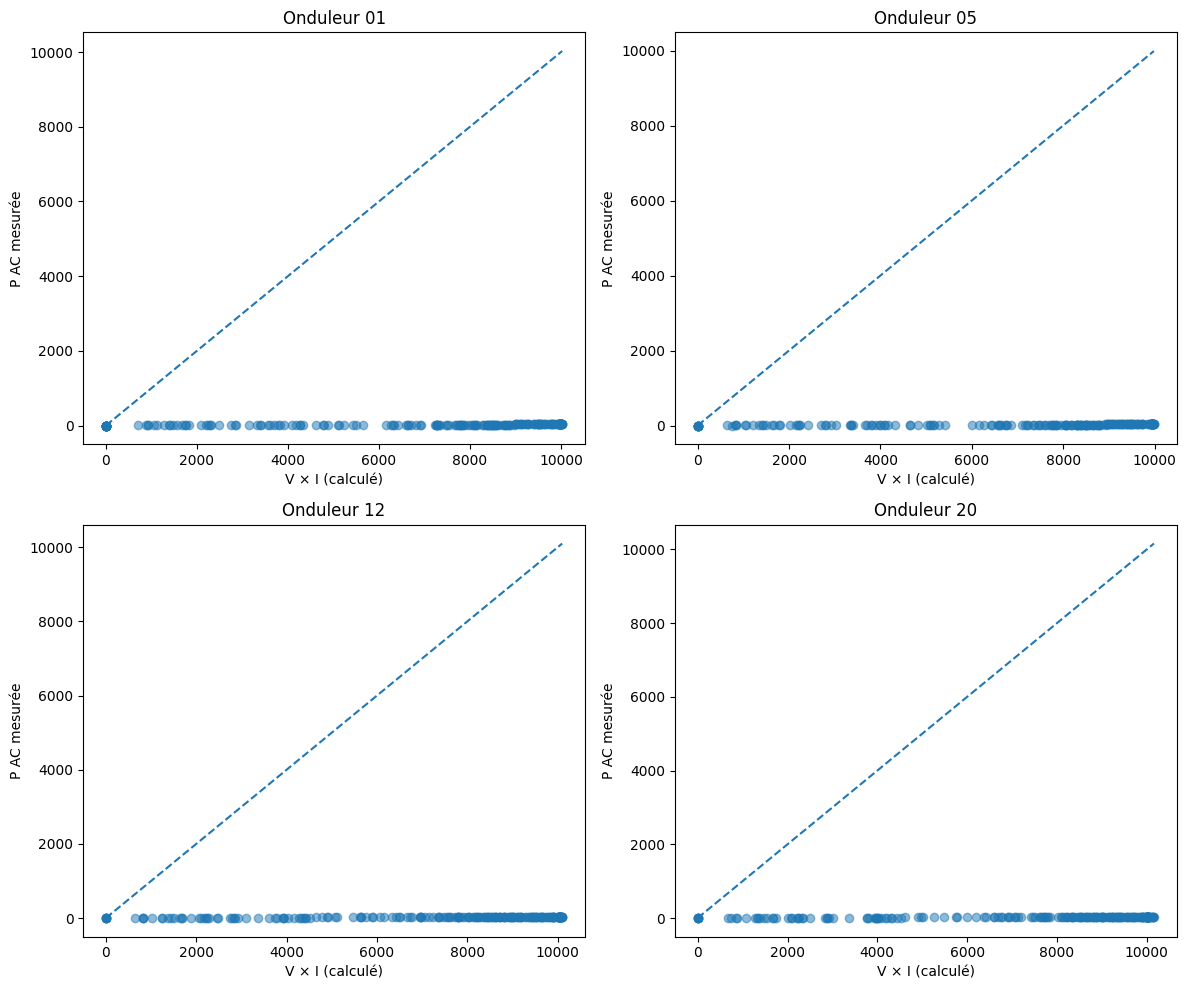

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, inv in zip(axes, inverters):
    ax.scatter(
        sample[f'inv_{inv:02d}_p_calc'],
        sample[f'inv_{inv:02d}_ac_power'],
        alpha=0.5
    )
    ax.plot(
        [0, sample[f'inv_{inv:02d}_p_calc'].max()],
        [0, sample[f'inv_{inv:02d}_p_calc'].max()],
        linestyle='--'
    )
    ax.set_title(f'Onduleur {inv:02d}')
    ax.set_xlabel('V × I (calculé)')
    ax.set_ylabel('P AC mesurée')

plt.tight_layout()
plt.show()


### Corrélation statistique pour TOUS les onduleurs

Corrélation de Pearson entre ac_power et ac_voltage × ac_current

In [14]:
correlations = {}

for inv in range(1, 25):
    cols = [
        f'inv_{inv:02d}_ac_voltage',
        f'inv_{inv:02d}_ac_current',
        f'inv_{inv:02d}_ac_power'
    ]
    
    tmp = df[cols].dropna()
    if len(tmp) > 100:
        p_calc = tmp[cols[0]] * tmp[cols[1]]
        corr = tmp[cols[2]].corr(p_calc)
        correlations[f'inv_{inv:02d}'] = corr

corr_series = pd.Series(correlations)
corr_series


inv_01    0.999545
inv_02    0.999300
inv_03    0.999449
inv_04    0.001407
inv_05    0.999532
inv_06    0.999586
inv_07    0.999559
inv_08    0.999329
inv_09    0.999495
inv_10    0.999280
inv_11    0.999592
inv_12    0.999615
inv_13    0.999590
inv_14    0.999386
inv_15    0.999609
inv_16    0.999121
inv_17    0.999278
inv_18    0.999563
inv_19    0.999463
inv_20    0.999612
inv_21    0.999080
inv_22    0.999583
inv_23    0.999258
inv_24    0.999120
dtype: float64

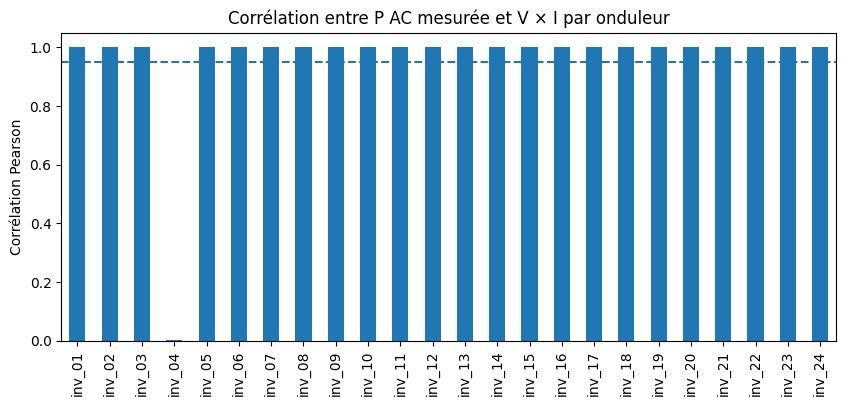

In [15]:
plt.figure(figsize=(10, 4))
corr_series.plot(kind='bar')
plt.axhline(0.95, linestyle='--')
plt.ylabel('Corrélation Pearson')
plt.title('Corrélation entre P AC mesurée et V × I par onduleur')
plt.show()

#### Diagnosis of inverter inv_04

In [16]:
cols_04 = [
    'inv_04_ac_voltage',
    'inv_04_ac_current',
    'inv_04_ac_power'
]

df_04 = df[cols_04]

df_04.describe()


,inv_04_ac_voltage,inv_04_ac_current,inv_04_ac_power
count,719339.000000,7.193390e+05,719339.000000
mean,135.842458,1.299878e+05,6.299665
std,143.972468,1.102414e+08,9.943366
min,0.000000,0.000000e+00,0.000000
25%,0.000000,0.000000e+00,0.000000
50%,0.000000,0.000000e+00,0.000000
75%,288.004000,1.219200e+01,10.386000
max,347.127000,9.350000e+10,103.710000


In [17]:
df_04.var()


inv_04_ac_voltage    2.072807e+04
inv_04_ac_current    1.215317e+16
inv_04_ac_power      9.887054e+01
dtype: float64

## Description générale du dataset

Le jeu de données utilisé ici ne contient **que les données électriques** (aucune jointure avec des données météorologiques ou d’irradiance à ce stade).

**Dimensions :**
- **Nombre de lignes** : 721 067
- **Nombre de colonnes** : 121
- **Résolution temporelle** : ≈ 5 minutes
- **Nombre moyen de points par jour** : ~288

**Plage temporelle :**
- Début : `2017-11-01 00:00:00`
- Fin : `2024-11-01 23:55:00`

---

### 3. Structure des variables électriques

Chaque onduleur (`inv_01` à `inv_24`) est associé à plusieurs grandeurs électriques mesurées côté DC et AC.

**Types de mesures disponibles :**
- **DC**
  - `dc_current` : courant continu
  - `dc_voltage` : tension continue
- **AC**
  - `ac_current` : courant alternatif
  - `ac_voltage` : tension alternative
  - `ac_power` : puissance active injectée


- Les mesures sont très liées entre elles pour chaque onduleur.
  Par exemple, ac_power dépend directement de ac_voltage et ac_current.

  Pour 23 onduleurs sur 24, la puissance AC calculée (V_AC × I_AC) est presque identique à la puissance mesurée (ac_power) avec une corrélation > 0,999, ce qui confirme la cohérence des données.

- Exception : `inv_04`

  La corrélation est proche de zéro.
  Le courant AC rapporté atteint des valeurs irréalistes (jusqu’à 9,3 × 10¹⁰ A), alors que la tension et la puissance restent plausibles.
  Cela montre un problème de capteur, de corruption des données ou de mauvaise configuration.
  On exclut donc cet onduleur pour les analyses physiques et la détection d’anomalies.


---

### 5. Analyse statistique globale

**Distribution des valeurs :**
- Présence de nombreuses valeurs nulles (`0`) :
  - correspondant aux périodes nocturnes,
  - ou à des onduleurs à l’arrêt.

- Les statistiques (quartiles, médiane) confirment :
  - une production intermittente,
  - des profils typiques jour/nuit bien marqués.

**Exemples de plages observées :**
- Tension DC : jusqu’à ~900 V
- Courant DC : jusqu’à ~55 A
- Puissance AC : jusqu’à ~30 kW par onduleur

---

### 6. Valeurs manquantes : analyse et interprétation

Un nombre significatif de valeurs manquantes est observé sur la majorité des canaux :

- De quelques centaines à plusieurs milliers de points manquants par variable
- Certaines colonnes très incomplètes (ex. `inv_05_dc_voltage`)

**Interprétation physique des valeurs manquantes :**
Il y a beaucoup de valeurs manquantes sur presque tous les canaux : 
- de quelques centaines à plusieurs milliers de points par variable
- certaines colonnes très incomplètes (ex. inv_05_dc_voltage)

Signification physique :
Les valeurs manquantes ne sont pas du bruit mais portent de l’information :
- onduleur hors ligne
- problème de communication
- arrêt de production
- maintenance ou panne

Décision de pré-traitement :
  On conserve les valeurs manquantes.

Les remplir ou interpoler pourrait :
- masquer de vraies anomalies
- créer de la production fictive
- fausser la détection d’ombres ou de défauts


---


### Supression des colonnes qui concernent l'onduleur numéro 4

In [18]:
cols_to_drop = [c for c in df.columns if c.startswith('inv_04_')]
df = df.drop(columns=cols_to_drop)

## **Visualisations**

In [19]:
# Colonnes de puissance AC
ac_power_cols = [c for c in df.columns if c.endswith('_ac_power')]

# Ajout de colonnes temporelles utiles
df['date'] = df['measured_on'].dt.date
df['hour'] = df['measured_on'].dt.hour
df['month'] = df['measured_on'].dt.month
df['year'] = df['measured_on'].dt.year

# Puissance totale du champ
df['P_ac_total'] = df[ac_power_cols].sum(axis=1)


C:\Users\Claire\AppData\Local\Temp\ipykernel_26644\3445816766.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['date'] = df['measured_on'].dt.date
C:\Users\Claire\AppData\Local\Temp\ipykernel_26644\3445816766.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['hour'] = df['measured_on'].dt.hour
C:\Users\Claire\AppData\Local\Temp\ipykernel_26644\3445816766.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider join

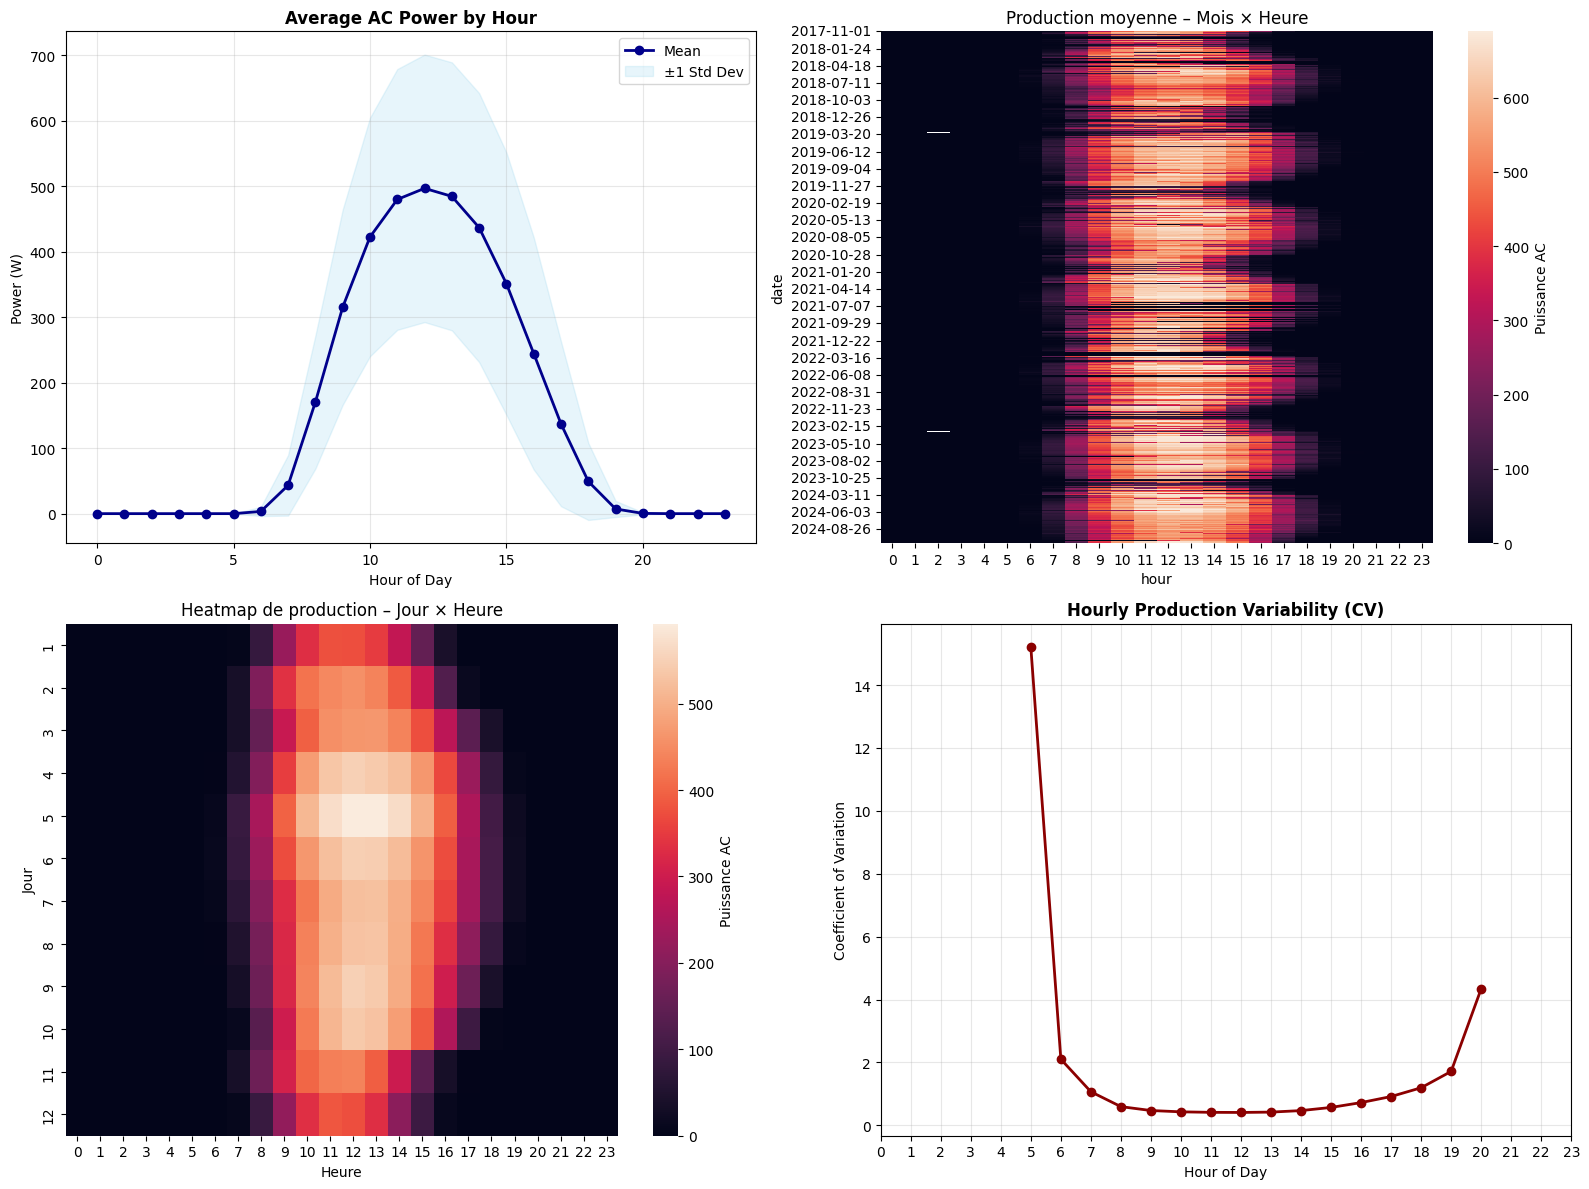

In [20]:
hourly_power = df.groupby("hour")["P_ac_total"].agg(['mean', 'std'])

# Pivot tables for heatmaps
pivot_day_hour = df.pivot_table(
    values='P_ac_total',
    index='date',
    columns='hour',
    aggfunc='mean'
)

pivot_month_hour = df.pivot_table(
    values='P_ac_total',
    index='month',
    columns='hour',
    aggfunc='mean'
)

# Create 2x2 figure
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()  # flatten to 1D for easy indexing

# -----------------------------
# Panel 1: Hourly AC power
axes[0].plot(hourly_power.index, hourly_power['mean'], marker='o', linewidth=2, color='darkblue', label='Mean')
axes[0].fill_between(hourly_power.index, 
                     hourly_power['mean'] - hourly_power['std'],
                     hourly_power['mean'] + hourly_power['std'],
                     alpha=0.2, color='skyblue', label='±1 Std Dev')
axes[0].set_title("Average AC Power by Hour", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Hour of Day")
axes[0].set_ylabel("Power (W)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# -----------------------------
# Panel 2: Heatmap – Month × Hour
sns.heatmap(pivot_month_hour, ax=axes[2], cbar_kws={'label': 'Puissance AC'})
axes[1].set_xlabel('Heure')
axes[1].set_ylabel('Mois')
axes[1].set_title('Production moyenne – Mois × Heure')

# -----------------------------
# Panel 3: Heatmap – Day × Hour
sns.heatmap(pivot_day_hour, ax=axes[1], cbar_kws={'label': 'Puissance AC'})
axes[2].set_xlabel('Heure')
axes[2].set_ylabel('Jour')
axes[2].set_title('Heatmap de production – Jour × Heure')


# -----------------------------
# Panel 4: Hourly variability (Coefficient of Variation)
hourly_cv = (
    df.groupby("hour")["P_ac_total"].std() /
    df.groupby("hour")["P_ac_total"].mean()
)

axes[3].plot(
    hourly_cv.index,
    hourly_cv.values,
    marker='o',
    linewidth=2,
    color='darkred'
)

axes[3].set_title("Hourly Production Variability (CV)", fontsize=12, fontweight='bold')
axes[3].set_xlabel("Hour of Day")
axes[3].set_ylabel("Coefficient of Variation")
axes[3].grid(True, alpha=0.3)
axes[3].set_xticks(range(0, 24))

plt.tight_layout()
plt.show()

C:\Users\Claire\AppData\Local\Temp\ipykernel_26644\2054489880.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['season'] = df['month'].apply(get_season)


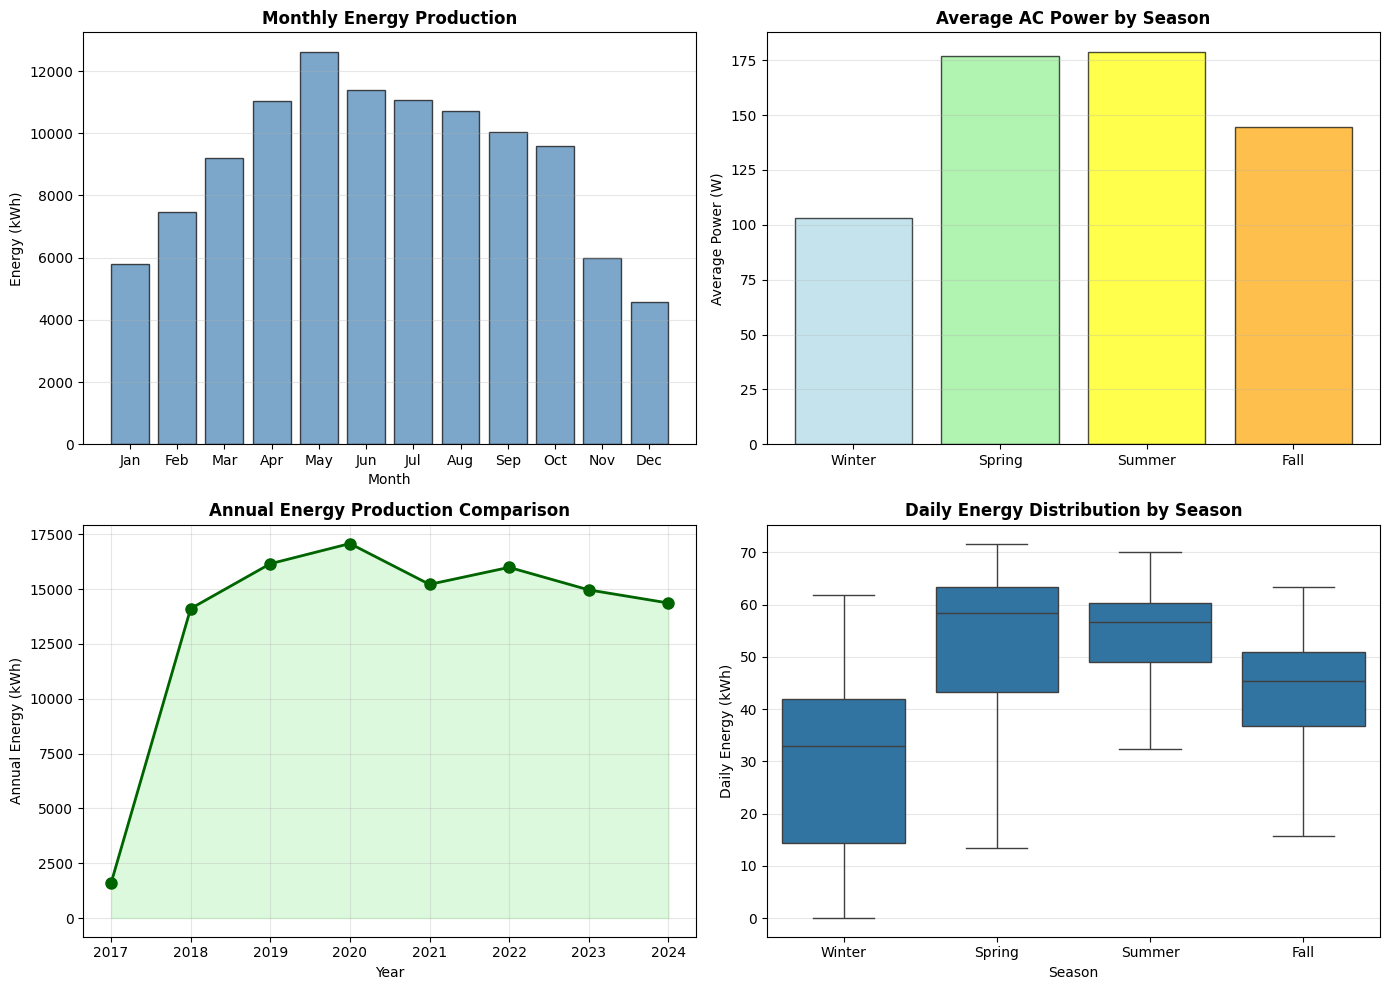

In [21]:
import matplotlib.pyplot as plt

# Make sure 'season' column exists
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Fall"
    
df['season'] = df['month'].apply(get_season)

# Create 2x2 subplot grid
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()  # flatten to 1D array for easy indexing: axes[0], axes[1], axes[2], axes[3]

# -----------------------------
# Panel 1: Monthly energy production
monthly_energy = df.groupby("month")["P_ac_total"].sum() / 1000  # kWh
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

axes[0].bar(range(1, 13), [monthly_energy.get(m, 0) for m in range(1, 13)], 
            edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_title("Monthly Energy Production", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Energy (kWh)")
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(month_names)
axes[0].grid(True, alpha=0.3, axis='y')

# -----------------------------
# Panel 2: Average AC Power by Season
seasonal_stats = df.groupby("season").agg({
    "P_ac_total": ["mean", "sum"]
})
seasons_order = ["Winter", "Spring", "Summer", "Fall"]
seasonal_power = [seasonal_stats.loc[s, ("P_ac_total", "mean")] if s in seasonal_stats.index else 0 for s in seasons_order]

axes[1].bar(seasons_order, seasonal_power, 
            edgecolor='black', alpha=0.7, color=['lightblue', 'lightgreen', 'yellow', 'orange'])
axes[1].set_title("Average AC Power by Season", fontsize=12, fontweight='bold')
axes[1].set_ylabel("Average Power (W)")
axes[1].grid(True, alpha=0.3, axis='y')

# -----------------------------
# Panel 3: Annual Energy Production Comparison
yearly_energy = df.groupby("year")["P_ac_total"].sum() / 1000  # kWh

axes[2].plot(yearly_energy.index, yearly_energy.values, marker='o', linewidth=2, markersize=8, color='darkgreen')
axes[2].fill_between(yearly_energy.index, yearly_energy.values, alpha=0.3, color='lightgreen')
axes[2].set_title("Annual Energy Production Comparison", fontsize=12, fontweight='bold')
axes[2].set_xlabel("Year")
axes[2].set_ylabel("Annual Energy (kWh)")
axes[2].grid(True, alpha=0.3)

# -----------------------------
# Panel 4: Daily energy distribution by season

daily_energy = df.groupby("date")["P_ac_total"].sum() / 1000  # kWh
daily_energy = daily_energy.to_frame(name="daily_energy")

# Recover season information per day
daily_energy["season"] = (
    df.groupby("date")["season"].first()
)

seasons_order = ["Winter", "Spring", "Summer", "Fall"]

sns.boxplot(
    x="season",
    y="daily_energy",
    data=daily_energy,
    order=seasons_order,
    ax=axes[3],
    showfliers=False
)

axes[3].set_title("Daily Energy Distribution by Season", fontsize=12, fontweight='bold')
axes[3].set_xlabel("Season")
axes[3].set_ylabel("Daily Energy (kWh)")
axes[3].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


#### Corrélations & redondance des features

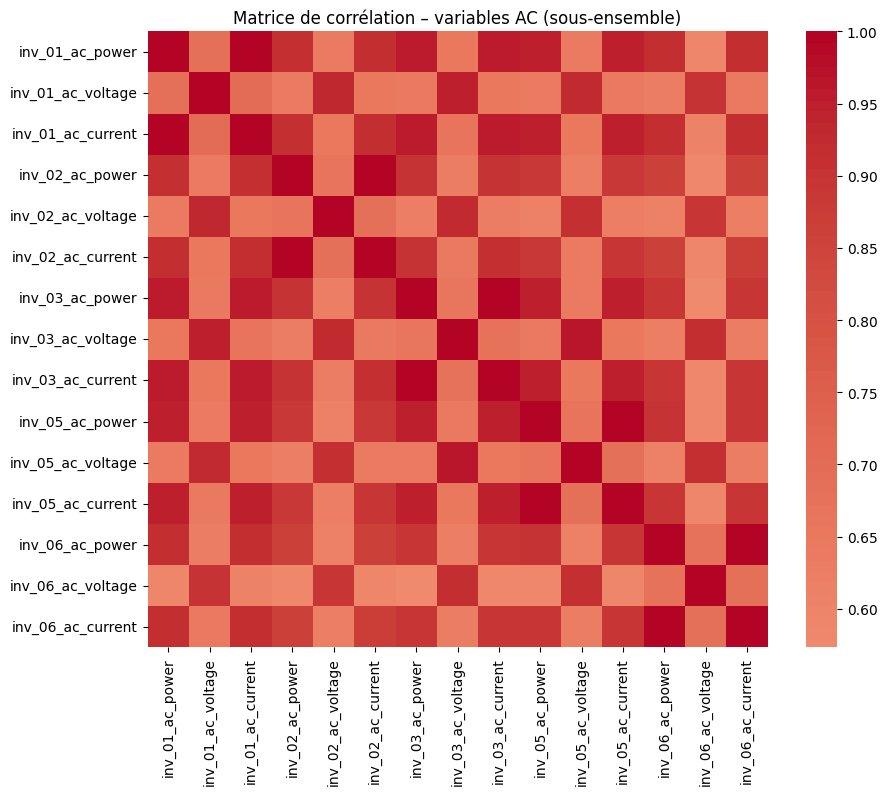

In [22]:
example_inverters = [1, 2, 3, 5, 6]

corr_cols = []
for inv in example_inverters:
    corr_cols.extend([
        f'inv_{inv:02d}_ac_power',
        f'inv_{inv:02d}_ac_voltage',
        f'inv_{inv:02d}_ac_current'
    ])

corr_df = df[corr_cols].dropna().sample(5000, random_state=42)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_df.corr(), cmap='coolwarm', center=0)
plt.title('Matrice de corrélation – variables AC (sous-ensemble)')
plt.show()


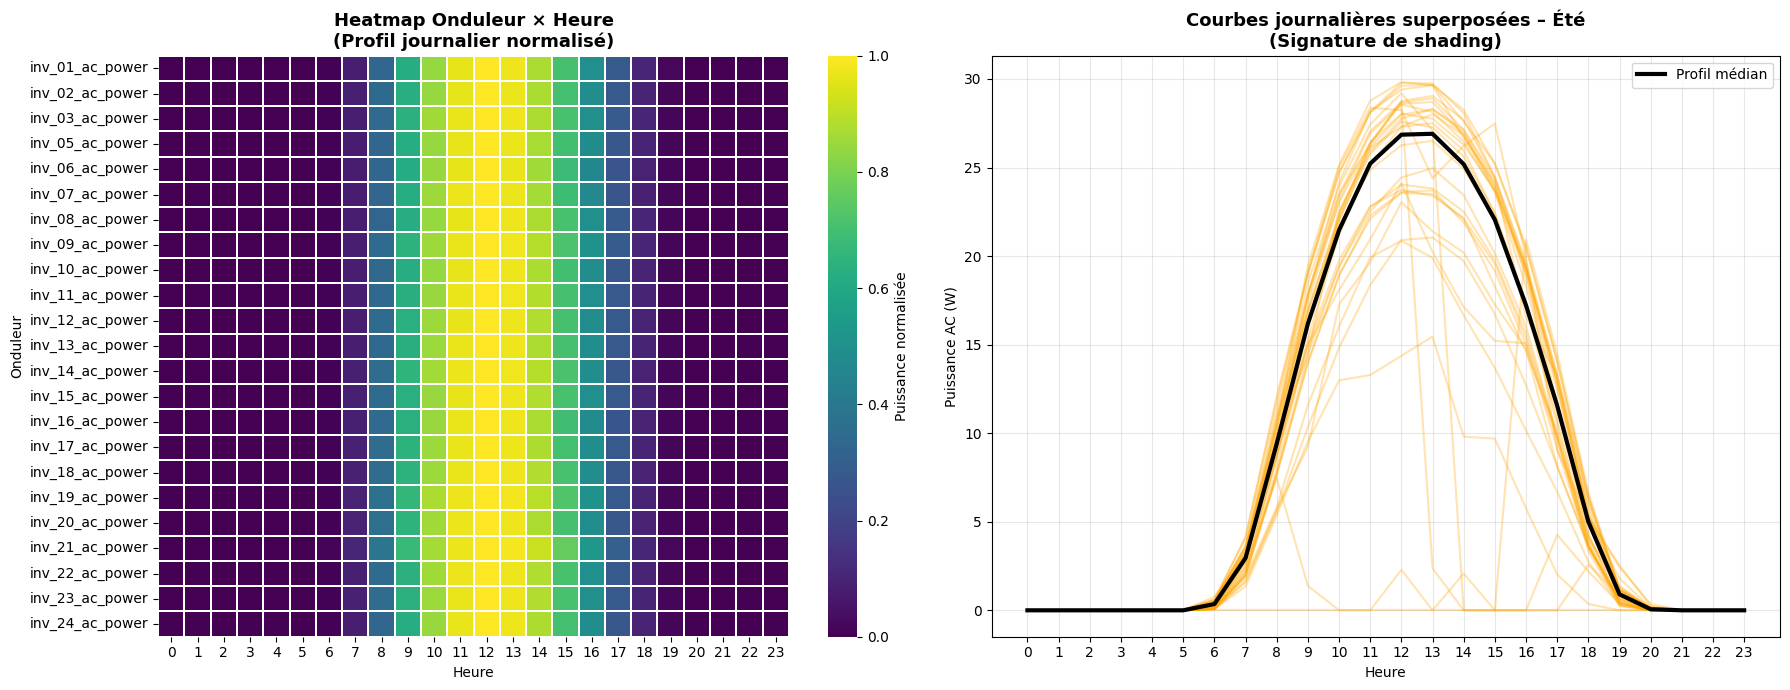

In [23]:
inv_power_cols = [c for c in df.columns if c.endswith("_ac_power")]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ======================================================
# PANEL 1 — Heatmap Onduleur × Heure
# ======================================================

# Moyenne horaire par onduleur
pivot_inv_hour = (
    df.groupby("hour")[inv_power_cols]
      .mean()
      .T
)

# Normalisation par onduleur (forme uniquement)
pivot_inv_hour_norm = pivot_inv_hour.div(pivot_inv_hour.max(axis=1), axis=0)

sns.heatmap(
    pivot_inv_hour_norm,
    ax=axes[0],
    cmap="viridis",
    cbar_kws={"label": "Puissance normalisée"},
    linewidths=0.1
)

axes[0].set_title("Heatmap Onduleur × Heure\n(Profil journalier normalisé)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Heure")
axes[0].set_ylabel("Onduleur")

# ======================================================
# PANEL 2 — Courbes journalières superposées (été)
# ======================================================

# Sélection été (juin–août)
summer_df = df[df["month"].isin([6, 7, 8])]

# Sélection d'un onduleur représentatif
inv_example = "inv_01_ac_power"

# Moyenne horaire par jour
daily_profiles = (
    summer_df
    .groupby(["date", "hour"])[inv_example]
    .mean()
    .unstack()
)

# Échantillon de journées (lisibilité)
daily_profiles_sample = daily_profiles.sample(
    n=min(30, len(daily_profiles)),
    random_state=42
)

for _, row in daily_profiles_sample.iterrows():
    axes[1].plot(row.index, row.values, color="orange", alpha=0.3)

# Profil médian (référence)
median_profile = daily_profiles.median()
axes[1].plot(
    median_profile.index,
    median_profile.values,
    color="black",
    linewidth=3,
    label="Profil médian"
)

axes[1].set_title("Courbes journalières superposées – Été\n(Signature de shading)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Heure")
axes[1].set_ylabel("Puissance AC (W)")
axes[1].set_xticks(range(0, 24))
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

## Analyse exploratoire de la production photovoltaïque

Les graphiques permettent de comprendre comment le parc photovoltaïque produit de l’électricité à différentes périodes (heure, jour, mois, année) et de vérifier si les données sont cohérentes avec la réalité.

### 1. Production au cours de la journée

La production électrique suit le rythme classique d’un panneau solaire :
- zéro production la nuit,
- augmentation progressive le matin,
- pic autour de midi,
- baisse symétrique l’après-midi.

La variabilité change selon l’heure :
- forte le matin et le soir,
- faible autour du pic solaire.

---

### 2. Variations selon le temps et la météo

Les heatmaps (jour × heure et mois × heure) montrent :
- des jours avec très peu de production,
- des journées plus longues et plus productives en été,
- des journées plus courtes et moins productives en hiver.

En général, la production suit le cycle naturel des saisons.

---
### 3. Effets des saisons et des mois

La production mensuelle montre :
- un maximum au printemps et au début de l’été,
- une légère baisse en plein été,
- un minimum en hiver.

Cette baisse en été, alors que le soleil est fort, peut sembler surprenante.

---
### 4. Évolution sur plusieurs années

L’analyse annuelle indique :
- une forte augmentation entre 2017 et 2018 (2017 ne couvre que novembre et décembre),
- une production stable sur les années récentes,
- pas de chute brutale ni de problème majeur.

Le système est donc stable et ne montre pas de dégradation importante sur plusieurs années.

---
### 5. Production quotidienne selon la saison

La production journalière par saison montre :
- beaucoup de variations en hiver (météo changeante),
- production plus élevée et régulière en été,
- printemps particulièrement performant et stable.

--- 

### 6. Cohérence des onduleurs (Heatmap Onduleur × Heure)

La heatmap montre le profil journalier normalisé de la puissance AC pour chaque onduleur.

Observations principales :
- Tous les onduleurs suivent le même cycle journalier :
  - production nulle la nuit,
  - augmentation le matin,
  - pic autour de midi,
  - baisse progressive en fin de journée.
- Les profils sont très similaires d’un onduleur à l’autre, ce qui indique :
  - un fonctionnement globalement homogène du parc,
  - une exposition solaire comparable pour l’ensemble des onduleurs.
- L’absence de bandes horizontales sombres persistantes suggère qu’il n’y a pas d’onduleur durablement sous-performant.

Interprétation :
- La production est dominée par la position du soleil.
- Les onduleurs peuvent être comparés entre eux sans biais.

---

### 7. Variabilité journalière estivale (Courbes superposées)

Les courbes représentent la production horaire de plusieurs journées d’été, superposées pour un même onduleur, avec un profil médian de référence.

Observations principales :
- La majorité des journées suivent une forme en cloche régulière.
- Le pic de production est stable et centré autour de la mi-journée.
- Certaines journées présentent des creux ou une production plus faible à certaines heures.

Interprétation :
- Les journées proches du profil médian correspondent à des conditions météo favorables.
- Les écarts ponctuels sont probablement dus à :
  - des passages nuageux,
  - des ombrages temporaires,
  - ou des pertes transitoires de performance.
- L’absence de creux systématique à la même heure suggère qu’il n’y a pas d’ombrage fixe dominant sur l’onduleur analysé.

---

## **Utilisation de Solar Data Tools**

### Etude de l'ombrage avec le module `ShadeAnalysis`

In [24]:
dh=DataHandler(df, datetime_col="measured_on")

dh.run_pipeline(power_col='P_ac_total')


            *********************************************
            * Solar Data Tools Data Onboarding Pipeline *
            *********************************************

            This pipeline runs a series of preprocessing, cleaning, and quality
            control tasks on stand-alone PV power or irradiance time series data.
            After the pipeline is run, the data may be plotted, filtered, or
            further analyzed.

            Authors: Bennet Meyers and Sara Miskovich, SLAC

            (Tip: if you have a mosek [https://www.mosek.com/] license and have it
            installed on your system, try setting solver='MOSEK' for a speedup)

            This material is based upon work supported by the U.S. Department
            of Energy's Office of Energy Efficiency and Renewable Energy (EERE)
            under the Solar Energy Technologies Office Award Number 38529.

            


task list: 100%|██████████████████████████████████| 7/7 [03:21<00:00, 28.83s/it]



total time: 202.02 seconds
--------------------------------
Breakdown
--------------------------------
Preprocessing              75.40s
Cleaning                   2.12s
Filtering/Summarizing      124.49s
    Data quality           2.98s
    Clear day detect       4.06s
    Clipping detect        55.93s
    Capacity change detect 61.50s



(CVXPY) Jan 07 03:48:12 PM: Your problem has 36378 variables, 59742 constraints, and 1536 parameters.
(CVXPY) Jan 07 03:48:12 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Jan 07 03:48:12 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Jan 07 03:48:12 PM: Your problem is compiled with the CPP canonicalization backend.
(CVXPY) Jan 07 03:48:12 PM: Compiling problem (target solver=CLARABEL).
(CVXPY) Jan 07 03:48:12 PM: Reduction chain: Dcp2Cone -> CvxAttr2Constr -> ConeMatrixStuffing -> CLARABEL
(CVXPY) Jan 07 03:48:12 PM: Applying reduction Dcp2Cone
(CVXPY) Jan 07 03:48:13 PM: Applying reduction CvxAttr2Constr
(CVXPY) Jan 07 03:48:13 PM: Applying reduction ConeMatrixStuffing


                                     CVXPY                                     
                                     v1.7.5                                    
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------


(CVXPY) Jan 07 03:48:14 PM: Applying reduction CLARABEL
(CVXPY) Jan 07 03:48:14 PM: Finished problem compilation (took 1.509e+00 seconds).
(CVXPY) Jan 07 03:48:14 PM: (Subsequent compilations of this problem, using the same arguments, should take less time.)
(CVXPY) Jan 07 03:48:14 PM: Invoking solver CLARABEL  to obtain a solution.


-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------
-------------------------------------------------------------
           Clarabel.rs v0.11.1  -  Clever Acronym                

                   (c) Paul Goulart                          
                University of Oxford, 2022                   
-------------------------------------------------------------

problem:
  variables     = 95420
  constraints   = 130816
  nnz(P)        = 47010
  nnz(A)        = 451302
  cones (total) = 2
    :        Zero = 1,  numel = 71168
    : Nonnegative = 1,  numel = 59648

settings:
  linear algebra: direct / faer, precision: 64 bit (8 threads)
  max iter = 200, time limit = Inf,  max step = 0.990
  tol_feas = 1.0e-8, tol_gap_abs = 1.0e-8, tol_gap_rel = 1.0e-8,
  static reg : on, ϵ1 = 1.0e-8, ϵ2 = 4.9e-32
  d

c:\Users\Claire\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\cvxpy\problems\problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
(CVXPY) Jan 07 03:54:34 PM: Problem status: optimal_inaccurate
(CVXPY) Jan 07 03:54:34 PM: Optimal value: 5.175e+02
(CVXPY) Jan 07 03:54:34 PM: Compilation took 1.509e+00 seconds
(CVXPY) Jan 07 03:54:34 PM: Solver (including time spent in interface) took 3.795e+02 seconds


200  +5.1753e+02  +5.1753e+02  5.42e-07  6.10e-08  2.08e-14  1.09e-09  3.80e-11  5.84e-01  
---------------------------------------------------------------------------------------------
Terminated with status = AlmostSolved
solve time = 379.1069007s
-------------------------------------------------------------------------------
                                    Summary                                    
-------------------------------------------------------------------------------
True
component arg must be one of ['clear', 'shade', 'residual']


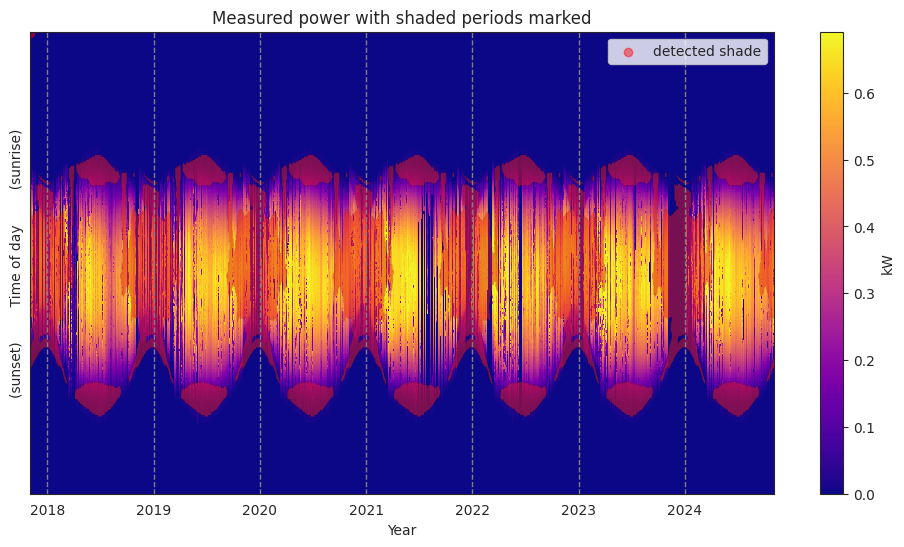

In [25]:
shade = ShadeAnalysis(data_handler=dh, matrix=None)

# Run the shading detection
shade.run(power=8, solver='CLARABEL', verbose=True)

# Check if the analysis ran
print(shade.has_run)  # True if completed

# Plot heatmap of shading anomalies
shade.plot_annotated_heatmap(figsize=(12,6))

# component analysis
shade.plot_component('shading')

## **Filtrer les périodes de Clear Sky avec pvlib**

In [26]:
# Paramètres du site
latitude = 38.996306
longitude = -122.134111
tz = 'US/Central'
tilt = 25
azimuth = 180

df_elec=df.copy()

df_elec.index = pd.to_datetime(df_elec.index)

df_elec.index = df_elec.index.tz_localize('UTC').tz_convert(tz)

# Créer l'objet site
site = pvlib.location.Location(latitude, longitude, tz=tz)

# Calcul de la position solaire
solar_pos = site.get_solarposition(df_elec.index)

# Calculer le clear sky POA avec pvlib
clearsky = site.get_clearsky(df_elec.index, model='ineichen')  # renvoie GHI, DNI, DHI

# Estimer le POA pour le tilt et azimuth du champ
poa = pvlib.irradiance.get_total_irradiance(
    surface_tilt=tilt,
    surface_azimuth=azimuth,
    dni=clearsky['dni'],
    ghi=clearsky['ghi'],
    dhi=clearsky['dhi'],
    solar_zenith=site.get_solarposition(df_elec.index)['zenith'],
    solar_azimuth=site.get_solarposition(df_elec.index)['azimuth']
)
poa_cs = poa['poa_global']

# Filtrer les périodes de ciel clair (>90% du POA max)
threshold = 0.9 * poa_cs.max()
df_clear = df_elec[poa_cs >= threshold]

In [27]:
print(f"Nombre de points sous ciel clair : {len(df_clear)}")
print(f"Nombre de points au total: {len(df)}")
print(f"Ratio de points clear-sky par rapport au nombre total de points: {len(df_clear)/len(df)*100:.2f}%")


Nombre de points sous ciel clair : 721067
Nombre de points au total: 721067
Ratio de points clear-sky par rapport au nombre total de points: 100.00%


## **Sauvegarde du dataset prétraité**

In [28]:
#df_clear.to_csv("farm_array_elec_clearsky.csv")

#or


#df.to_csv("farm_array_elec.csv")

# Statistical Shading Detection with Reference Panel

## Methodology Overview

This section implements a statistical approach for shading detection in PV arrays:

1. **Reference Panel Selection**: Choose an unshaded panel using correlation analysis
2. **Statistical Anomaly Detection**: Detect shading by comparing each panel to the reference

The method uses the clear-sky filtered data (`df_clear`) to avoid confounding shading with cloud effects.

## 1. Reference Panel Selection

We select a reference panel that is:
- **Highly correlated** with other panels (representative behavior)
- **Stable production** (low variance)
- **Complete data** (minimal missing values)

This panel is assumed to be unshaded and serves as the baseline for comparison.

### Reference Panel Correction Methodology

**Why correct the reference panel?**

Even the best-correlated panel can occasionally experience:
- Temporary shading
- Sensor errors
- Performance degradation
- Other anomalies

**Solution: Ensemble-based correction**

1. **Select top N panels** (default: 5) based on correlation
2. **Calculate ensemble reference** = median of top N panels
3. **Detect anomalies** in primary reference by comparing to ensemble
4. **Replace anomalous values** with ensemble median

**Benefits:**
- ✅ More robust reference (less sensitive to single panel issues)
- ✅ Reduces false positives in shading detection
- ✅ Automatic correction without manual intervention
- ✅ Maintains high accuracy when primary reference is clean

In [29]:
# Identify power columns
power_cols = [col for col in df_clear.columns if 'ac_power' in col and 'inv' in col]
print(f"📊 Found {len(power_cols)} inverter power channels")
print(f"   Analyzing clear-sky data: {len(df_clear):,} points")

# Calculate correlation matrix between all inverters
print("\n🔍 Analyzing inter-inverter correlations...")
corr_matrix = df_clear[power_cols].corr()

# Calculate average correlation for each inverter (excluding self-correlation)
corr_sums = corr_matrix.sum().sort_values(ascending=False)
corr_avg = (corr_sums - 1) / (len(power_cols) - 1)  # Subtract 1 to exclude self-correlation

# Select the inverter with highest average correlation
reference_inv = corr_sums.index[0]

print(f"\n{'='*70}")
print(f"SELECTED REFERENCE PANEL: {reference_inv}")
print(f"{'='*70}")
print(f"Average correlation: {corr_avg.iloc[0]:.4f}")
print(f"Min correlation: {corr_matrix[reference_inv].drop(reference_inv).min():.4f}")
print(f"Max correlation: {corr_matrix[reference_inv].drop(reference_inv).max():.4f}")

📊 Found 23 inverter power channels
   Analyzing clear-sky data: 721,067 points

🔍 Analyzing inter-inverter correlations...

SELECTED REFERENCE PANEL: inv_11_ac_power
Average correlation: 0.9519
Min correlation: 0.8954
Max correlation: 0.9882


In [30]:
# Additional validation metrics
print(f"\n📊 Additional validation metrics:\n")

# Data completeness
missing_pct = df_clear[power_cols].isna().sum() / len(df_clear) * 100
ref_missing = missing_pct[reference_inv]
print(f"   Missing data: {ref_missing:.2f}% (rank {missing_pct.rank().loc[reference_inv]:.0f}/{len(power_cols)})")

# Production stability (coefficient of variation)
cv = df_clear[power_cols].std() / df_clear[power_cols].mean()
ref_cv = cv[reference_inv]
print(f"   Coefficient of variation: {ref_cv:.4f} (rank {cv.rank().loc[reference_inv]:.0f}/{len(power_cols)})")

# Median production relative to array average
median_powers = df_clear[power_cols].median()
ref_median = median_powers[reference_inv]
array_median = median_powers.median()
relative_production = (ref_median / array_median - 1) * 100
print(f"   Median production: {ref_median:.0f} W ({relative_production:+.1f}% vs array median)")

if abs(relative_production) < 10:
    print(f"   ✅ Reference panel is representative (within ±10% of median)")
else:
    print(f"   ⚠️ Reference panel deviates from median (check if acceptable)")


📊 Additional validation metrics:

   Missing data: 0.24% (rank 14/23)
   Coefficient of variation: 1.4678 (rank 2/23)
   Median production: 0 W (+nan% vs array median)
   ⚠️ Reference panel deviates from median (check if acceptable)


C:\Users\Claire\AppData\Local\Temp\ipykernel_26644\1144310309.py:18: RuntimeWarning: invalid value encountered in scalar divide
  relative_production = (ref_median / array_median - 1) * 100


C:\Users\Claire\AppData\Local\Temp\ipykernel_26644\2638084807.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax4.boxplot(data_for_box,


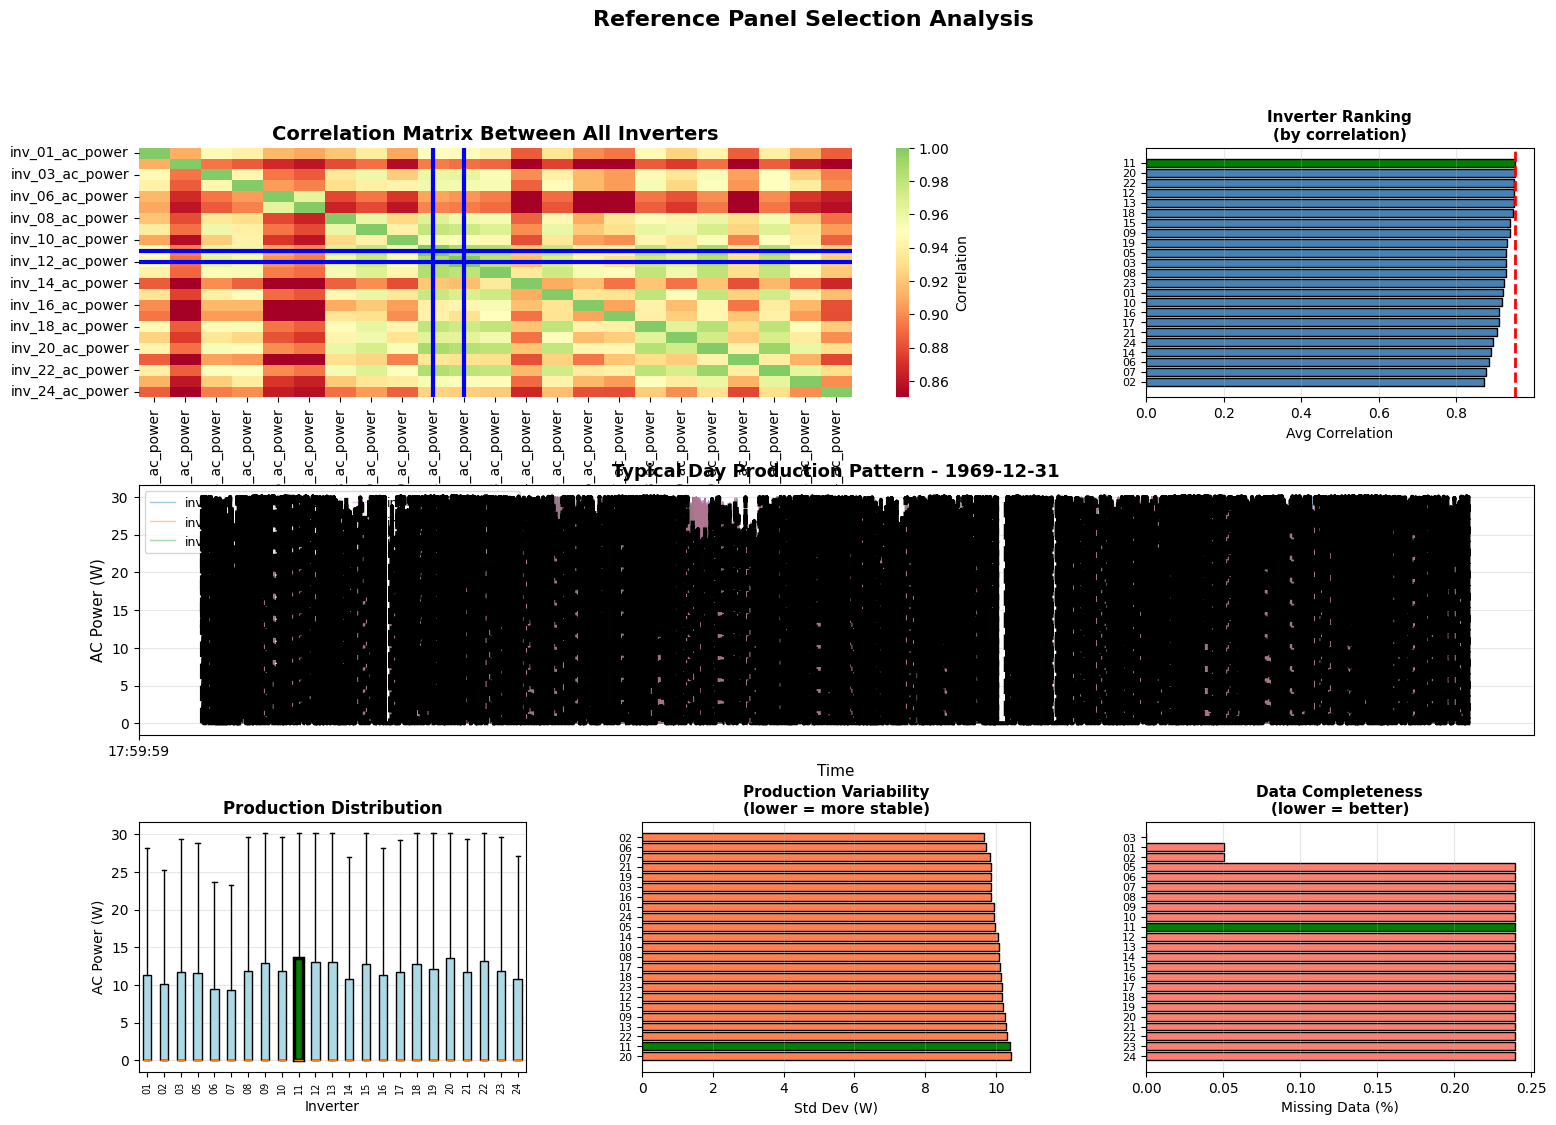


✅ Visualization saved as 'reference_panel_selection.png'


In [31]:
# Comprehensive visualization of reference panel selection
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)

# 1. Correlation matrix heatmap
ax1 = fig.add_subplot(gs[0, :2])
sns.heatmap(corr_matrix, annot=False, cmap='RdYlGn', center=0.95,
            vmin=0.85, vmax=1.0, ax=ax1, cbar_kws={'label': 'Correlation'})
ax1.set_title('Correlation Matrix Between All Inverters', fontsize=14, fontweight='bold')

# Highlight reference inverter
ref_idx = power_cols.index(reference_inv)
ax1.axhline(ref_idx + 0.5, color='blue', linewidth=3)
ax1.axhline(ref_idx + 1.5, color='blue', linewidth=3)
ax1.axvline(ref_idx + 0.5, color='blue', linewidth=3)
ax1.axvline(ref_idx + 1.5, color='blue', linewidth=3)

# 2. Average correlation ranking
ax2 = fig.add_subplot(gs[0, 2])
colors = ['green' if i == 0 else 'steelblue' for i in range(len(corr_avg))]
ax2.barh(range(len(corr_avg)), corr_avg.values, color=colors, edgecolor='black')
ax2.set_yticks(range(len(corr_avg)))
ax2.set_yticklabels([col.replace('inv_', '').replace('_ac_power', '') for col in corr_avg.index], 
                     fontsize=8)
ax2.set_xlabel('Avg Correlation', fontsize=10)
ax2.set_title('Inverter Ranking\n(by correlation)', fontsize=11, fontweight='bold')
ax2.invert_yaxis()
ax2.axvline(corr_avg.iloc[0], color='red', linestyle='--', linewidth=2)
ax2.grid(axis='x', alpha=0.3)

# 3. Typical day visualization
ax3 = fig.add_subplot(gs[1, :])
# Select a representative day with complete data
df_clear_copy = df_clear.copy()
df_clear_copy['date'] = df_clear_copy.index.date
daily_counts = df_clear_copy.groupby('date').size()
good_days = daily_counts[daily_counts > daily_counts.quantile(0.8)].index
sample_date = good_days[len(good_days)//2] if len(good_days) > 0 else df_clear_copy['date'].iloc[0]
sample_day = df_clear_copy[df_clear_copy['date'] == sample_date]

# Plot subset of inverters
for i, col in enumerate(power_cols[::3]):
    ax3.plot(sample_day.index, sample_day[col], 
             label=col.replace('_ac_power', ''), alpha=0.4, linewidth=1)

# Highlight reference in bold
ax3.plot(sample_day.index, sample_day[reference_inv],
         label=f'{reference_inv.replace("_ac_power", "")} (REFERENCE)',
         linewidth=3, color='black', linestyle='--', zorder=10)

ax3.set_title(f'Typical Day Production Pattern - {sample_date}', fontsize=13, fontweight='bold')
ax3.set_xlabel('Time', fontsize=11)
ax3.set_ylabel('AC Power (W)', fontsize=11)
ax3.legend(loc='upper left', fontsize=9, ncol=3)
ax3.grid(alpha=0.3)

# 4. Production distribution boxplot
ax4 = fig.add_subplot(gs[2, 0])
data_for_box = [df_clear[col].dropna() for col in power_cols]
bp = ax4.boxplot(data_for_box, 
                 labels=[col.replace('inv_', '').replace('_ac_power', '') for col in power_cols],
                 patch_artist=True, showfliers=False)

# Color reference box
for i, box in enumerate(bp['boxes']):
    if i == ref_idx:
        box.set_facecolor('green')
        box.set_linewidth(2.5)
    else:
        box.set_facecolor('lightblue')

ax4.set_title('Production Distribution', fontsize=12, fontweight='bold')
ax4.set_xlabel('Inverter', fontsize=10)
ax4.set_ylabel('AC Power (W)', fontsize=10)
ax4.tick_params(axis='x', rotation=90, labelsize=7)
ax4.grid(axis='y', alpha=0.3)

# 5. Production stability (std dev)
ax5 = fig.add_subplot(gs[2, 1])
power_std = df_clear[power_cols].std().sort_values()
colors_std = ['green' if col == reference_inv else 'coral' for col in power_std.index]
ax5.barh(range(len(power_std)), power_std.values, color=colors_std, edgecolor='black')
ax5.set_yticks(range(len(power_std)))
ax5.set_yticklabels([col.replace('inv_', '').replace('_ac_power', '') for col in power_std.index], 
                     fontsize=8)
ax5.set_xlabel('Std Dev (W)', fontsize=10)
ax5.set_title('Production Variability\n(lower = more stable)', fontsize=11, fontweight='bold')
ax5.invert_yaxis()
ax5.grid(axis='x', alpha=0.3)

# 6. Data completeness
ax6 = fig.add_subplot(gs[2, 2])
missing_sorted = missing_pct.sort_values()
colors_miss = ['green' if col == reference_inv else 'salmon' for col in missing_sorted.index]
ax6.barh(range(len(missing_sorted)), missing_sorted.values, color=colors_miss, edgecolor='black')
ax6.set_yticks(range(len(missing_sorted)))
ax6.set_yticklabels([col.replace('inv_', '').replace('_ac_power', '') for col in missing_sorted.index],
                     fontsize=8)
ax6.set_xlabel('Missing Data (%)', fontsize=10)
ax6.set_title('Data Completeness\n(lower = better)', fontsize=11, fontweight='bold')
ax6.invert_yaxis()
ax6.grid(axis='x', alpha=0.3)

plt.suptitle('Reference Panel Selection Analysis', fontsize=16, fontweight='bold', y=0.995)
plt.savefig('reference_panel_selection.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Visualization saved as 'reference_panel_selection.png'")

### 1.1 Corrected Reference Panel

Even the best-correlated panel might occasionally experience shading or performance issues. We create a **corrected reference** by:
1. Using the top N most correlated panels as backup references
2. Detecting anomalies in the primary reference
3. Replacing anomalous values with the median of the top N panels

In [32]:
# Select top N most correlated panels as reference candidates
N_REFERENCE_PANELS = 5  # Number of top panels to use for correction
top_panels = corr_avg.head(N_REFERENCE_PANELS).index.tolist()

print(f"🔧 Creating corrected reference using top {N_REFERENCE_PANELS} panels:")
for i, panel in enumerate(top_panels, 1):
    print(f"   {i}. {panel} (avg corr: {corr_avg.loc[panel]:.4f})")

# Create ensemble reference (median of top N panels)
df_clear['reference_ensemble'] = df_clear[top_panels].median(axis=1)

print(f"\n✅ Ensemble reference created from {N_REFERENCE_PANELS} panels")

🔧 Creating corrected reference using top 5 panels:
   1. inv_11_ac_power (avg corr: 0.9519)
   2. inv_20_ac_power (avg corr: 0.9516)
   3. inv_22_ac_power (avg corr: 0.9489)
   4. inv_12_ac_power (avg corr: 0.9489)
   5. inv_13_ac_power (avg corr: 0.9484)

✅ Ensemble reference created from 5 panels


In [33]:
def create_corrected_reference(df, primary_ref, top_panels, sigma_threshold=3.0):
    """
    Create a corrected reference by detecting and replacing anomalies in the primary reference.
    
    Parameters:
    -----------
    df : DataFrame
        Clear-sky filtered data
    primary_ref : str
        Primary reference panel column name
    top_panels : list
        List of top N panel column names (including primary)
    sigma_threshold : float
        Threshold for anomaly detection in primary reference
    
    Returns:
    --------
    tuple: (corrected_reference_series, correction_info_dict)
    """
    # Start with primary reference
    ref_corrected = df[primary_ref].copy()
    
    # Calculate ensemble reference (median of top N)
    ensemble_ref = df[top_panels].median(axis=1)
    
    # Detect anomalies in primary reference by comparing to ensemble
    # Calculate the ratio: primary / ensemble
    ratio = ref_corrected / ensemble_ref
    ratio = ratio.replace([np.inf, -np.inf], np.nan)
    
    # Use robust statistics for anomaly detection
    median_ratio = ratio.median()
    mad = np.median(np.abs(ratio - median_ratio))
    std_estimate = 1.4826 * mad
    
    # Define thresholds (both upper and lower bounds)
    lower_threshold = median_ratio - sigma_threshold * std_estimate
    upper_threshold = median_ratio + sigma_threshold * std_estimate
    
    # Identify anomalies (deviations from expected behavior)
    anomalies = (ratio < lower_threshold) | (ratio > upper_threshold)
    n_anomalies = anomalies.sum()
    
    # Replace anomalous values with ensemble median
    ref_corrected[anomalies] = ensemble_ref[anomalies]
    
    correction_info = {
        'n_corrections': n_anomalies,
        'correction_pct': n_anomalies / len(df) * 100,
        'median_ratio': median_ratio,
        'lower_threshold': lower_threshold,
        'upper_threshold': upper_threshold,
        'anomaly_mask': anomalies
    }
    
    return ref_corrected, correction_info

# Create corrected reference
reference_corrected, correction_info = create_corrected_reference(
    df_clear, 
    reference_inv, 
    top_panels,
    sigma_threshold=3.0
)

df_clear['reference_corrected'] = reference_corrected

print(f"\n📊 Reference Correction Statistics:")
print(f"   Anomalies detected: {correction_info['n_corrections']:,} points ({correction_info['correction_pct']:.3f}%)")
print(f"   Median ratio (primary/ensemble): {correction_info['median_ratio']:.4f}")
print(f"   Threshold range: [{correction_info['lower_threshold']:.4f}, {correction_info['upper_threshold']:.4f}]")

if correction_info['n_corrections'] > 0:
    print(f"   ✅ Corrected reference created with {correction_info['n_corrections']} points adjusted")
else:
    print(f"   ✅ Primary reference is clean - no corrections needed")


📊 Reference Correction Statistics:
   Anomalies detected: 0 points (0.000%)
   Median ratio (primary/ensemble): 0.9997
   Threshold range: [nan, nan]
   ✅ Primary reference is clean - no corrections needed



✅ No corrections were needed - primary reference is already optimal


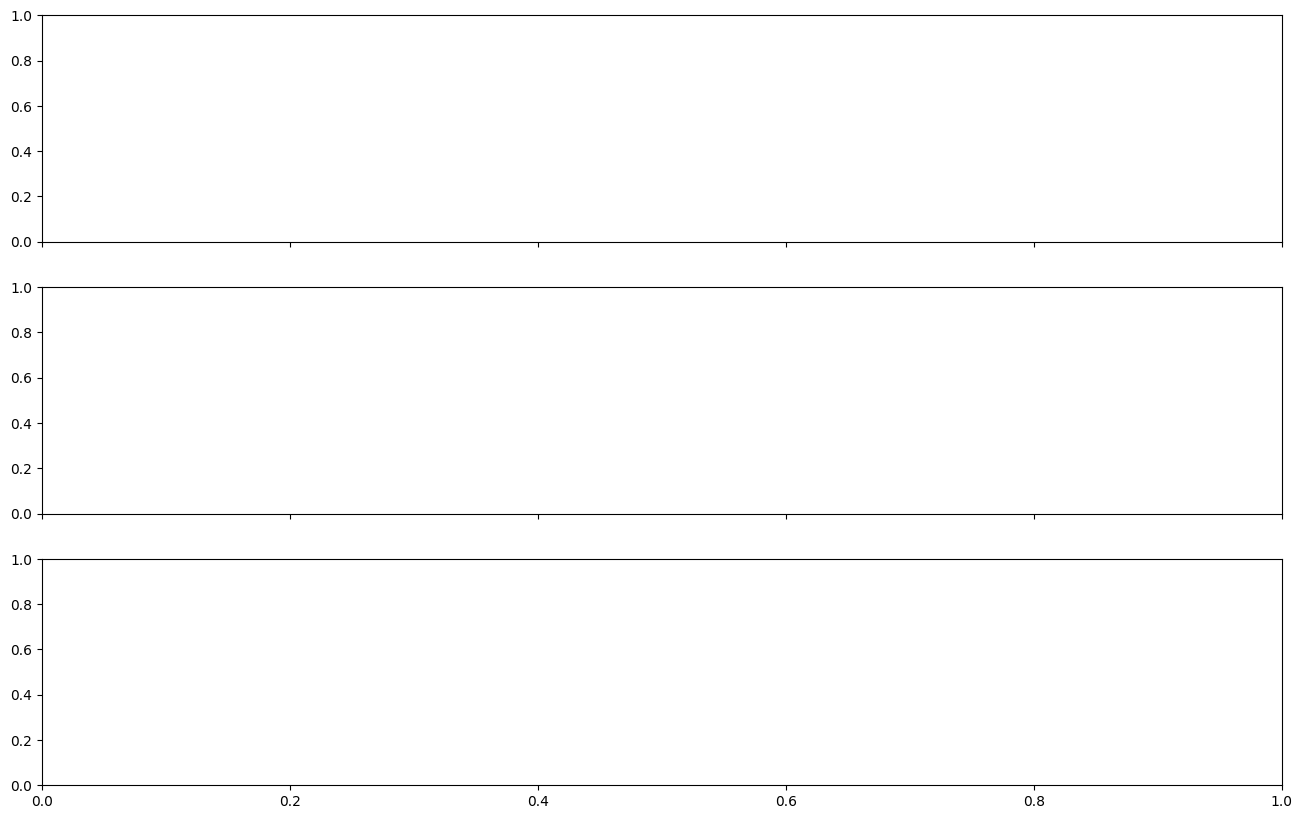

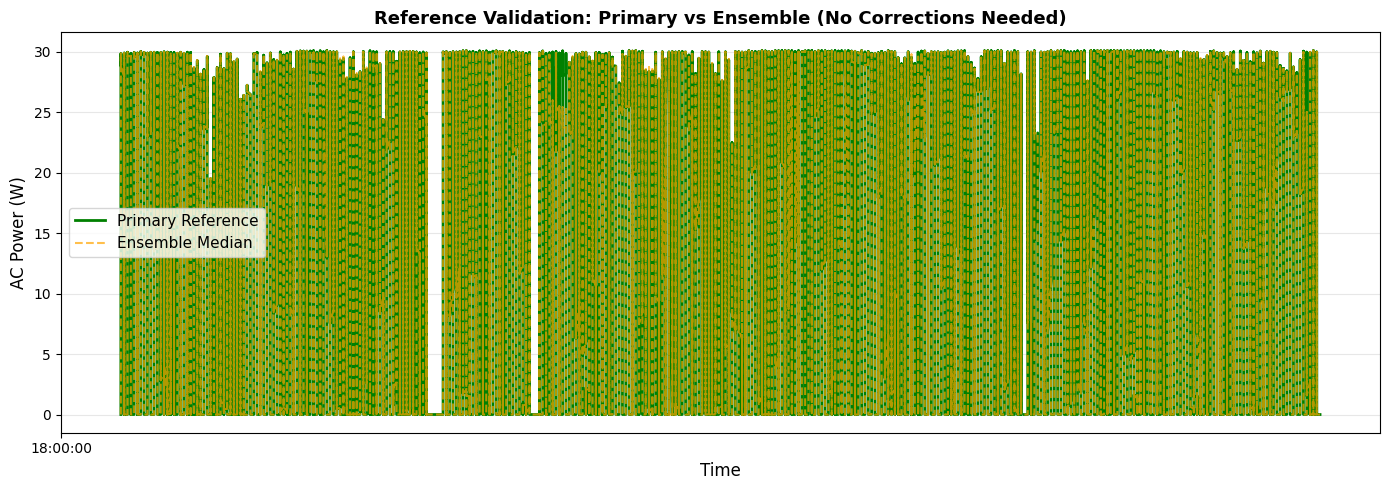

In [34]:
# Visualize the correction process
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

# Select a sample period to show corrections
if correction_info['n_corrections'] > 0:
    # Find a period with corrections
    correction_dates = df_clear[correction_info['anomaly_mask']].index.date
    if len(correction_dates) > 0:
        date_counts = pd.Series(correction_dates).value_counts()
        sample_date = date_counts.index[0]
        
        # Get surrounding days for context
        start_date = pd.Timestamp(sample_date) - pd.Timedelta(days=1)
        end_date = pd.Timestamp(sample_date) + pd.Timedelta(days=2)
        
        mask = (df_clear.index >= start_date) & (df_clear.index < end_date)
        sample_data = df_clear[mask]
        
        # Plot 1: Original vs Corrected Reference
        axes[0].plot(sample_data.index, sample_data[reference_inv],
                     label='Original Reference', linewidth=2, color='steelblue', alpha=0.7)
        axes[0].plot(sample_data.index, sample_data['reference_corrected'],
                     label='Corrected Reference', linewidth=2, color='green')
        axes[0].plot(sample_data.index, sample_data['reference_ensemble'],
                     label='Ensemble Median', linewidth=1.5, color='orange', linestyle='--', alpha=0.7)
        
        # Highlight corrected points
        corrected_in_sample = sample_data.index[correction_info['anomaly_mask'][mask]]
        if len(corrected_in_sample) > 0:
            axes[0].scatter(corrected_in_sample, sample_data.loc[corrected_in_sample, reference_inv],
                           color='red', s=100, zorder=5, marker='X', label='Corrected Points')
        
        axes[0].set_ylabel('AC Power (W)', fontsize=12)
        axes[0].set_title('Reference Panel Correction Process', fontsize=14, fontweight='bold')
        axes[0].legend(fontsize=10, loc='upper left')
        axes[0].grid(alpha=0.3)
        
        # Plot 2: Ratio (Primary / Ensemble)
        ratio_sample = (sample_data[reference_inv] / sample_data['reference_ensemble'])
        axes[1].plot(ratio_sample.index, ratio_sample, linewidth=1.5, color='purple', label='Primary/Ensemble Ratio')
        axes[1].axhline(correction_info['median_ratio'], color='green', linestyle='--', 
                       linewidth=2, label=f'Median ({correction_info["median_ratio"]:.3f})')
        axes[1].axhline(correction_info['lower_threshold'], color='red', linestyle='--',
                       linewidth=1.5, label='Lower Threshold')
        axes[1].axhline(correction_info['upper_threshold'], color='red', linestyle='--',
                       linewidth=1.5, label='Upper Threshold')
        
        # Shade anomaly regions
        axes[1].fill_between(ratio_sample.index, correction_info['lower_threshold'], 
                            correction_info['upper_threshold'], alpha=0.1, color='green', label='Normal Range')
        
        if len(corrected_in_sample) > 0:
            axes[1].scatter(corrected_in_sample, ratio_sample.loc[corrected_in_sample],
                           color='red', s=100, zorder=5, marker='X')
        
        axes[1].set_ylabel('Power Ratio', fontsize=12)
        axes[1].set_title('Anomaly Detection in Reference Panel', fontsize=13, fontweight='bold')
        axes[1].legend(fontsize=9, loc='upper left')
        axes[1].grid(alpha=0.3)
        
        # Plot 3: Top N panels comparison
        for panel in top_panels[:5]:  # Show top 5
            alpha = 1.0 if panel == reference_inv else 0.4
            linewidth = 2.5 if panel == reference_inv else 1.5
            label = f'{panel.replace("_ac_power", "")}' + (' (Primary)' if panel == reference_inv else '')
            axes[2].plot(sample_data.index, sample_data[panel], 
                        label=label, linewidth=linewidth, alpha=alpha)
        
        axes[2].set_ylabel('AC Power (W)', fontsize=12)
        axes[2].set_xlabel('Time', fontsize=12)
        axes[2].set_title(f'Top {N_REFERENCE_PANELS} Reference Candidates', fontsize=13, fontweight='bold')
        axes[2].legend(fontsize=9, loc='upper left')
        axes[2].grid(alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('reference_correction_process.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        print(f"\n✅ Correction visualization saved as 'reference_correction_process.png'")
        print(f"   Sample period: {start_date.date()} to {end_date.date()}")
        print(f"   Corrections in sample: {len(corrected_in_sample)}")
    else:
        print("No correction dates available for visualization")
else:
    print("\n✅ No corrections were needed - primary reference is already optimal")
    
    # Show comparison anyway for a sample period
    sample_start = df_clear.index[len(df_clear)//2]
    sample_end = sample_start + pd.Timedelta(days=3)
    mask = (df_clear.index >= sample_start) & (df_clear.index < sample_end)
    sample_data = df_clear[mask]
    
    fig, ax = plt.subplots(1, 1, figsize=(14, 5))
    ax.plot(sample_data.index, sample_data[reference_inv], 
            label='Primary Reference', linewidth=2, color='green')
    ax.plot(sample_data.index, sample_data['reference_ensemble'],
            label='Ensemble Median', linewidth=1.5, color='orange', linestyle='--', alpha=0.7)
    
    ax.set_ylabel('AC Power (W)', fontsize=12)
    ax.set_xlabel('Time', fontsize=12)
    ax.set_title('Reference Validation: Primary vs Ensemble (No Corrections Needed)', 
                 fontsize=13, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()